# Spherical Sky Regions

This (draft) pull request presents an implementation of spherical sky region classes. The spherical geometry of these classes is in contrast to the (implicit) planar geometry assumption of the current `SkyRegions` classes, which are directly related to `PixelRegions` and thus require a `WCS` object for methods such as `contains()`.

These spherical sky regions were developed as part of Roman upscope notebook preparation work, providing "helper class" functionality for how to specify a region in one coordinate frame (eg, a query region) and then transform that region into a different coordinate frame. In the future, these classes could also be used to, e.g., directly pass an instance for an astroquery search (though this would require code changes there) -- in addition to the myriad other cases where spherical geometry regions would be useful.

This notebook provides a brief demonstration of the functionality of these Spherical Sky Region classes:

1. Core `SphericalSkyRegion` class functionality:
    1. Spherical geometry implementation of `contains()` method
    1. Implements IVOA "Range" geometry
    1. Transform between coordinate frames with `transform_to()` (to implement: vetting of same frame origin)
    1. Other methods:
        - `bounding_circle(), bounding_lonlat()`: boundary information, useful for queries or pre-trimming tables before, e.g., using `contains()`
        - `discretize_boundary()`: a polygon approximation by discretizing the boundary(/ies), in order to account for boundary distortions in spherical to planar transformations.
2. Ability to convert to and from `SkyRegions` and `PixelRegions`
    - Note convert ***from*** planar regions ***to*** spherical regions with boundary distortions isn't yet implemented, as this would require implementing discretization of the planar shapes (in pixel space, guaranteeing planar geometry).
3. Ability to construct compound spherical sky regions (in the same manner as `SkyRegions` and `PixelRegions`)


**Outstanding tasks should this functionality be greenlit for inclusion in the package:**
- Test suite for `SphericalSkyRegion` classes
- Create documentation pages + demos for the new functionality (and edit other doc pages as necessary) --- based on the below demo, but chunked out into separate topical entries.
- Decision on handling of serialization for spherical regions (keyword switch to use spherical?), or add note to docs that serialization will default read in planar `SkyRegion` classes only.
- Decision on whether or not (and how) to implement planar -> spherical conversion if boundary distortions are to be included.

In [82]:
%matplotlib inline
import numpy as np
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u
import matplotlib.pyplot as plt

from regions import (
CircleSkyRegion, CircleSphericalSkyRegion,
RangeSphericalSkyRegion,
make_example_dataset,
)


config = dict(crval=(0, 0),
            crpix=(180, 90),
            cdelt=(-1, 1),
            shape=(180, 360),
            ctype=('RA---AIT', 'DEC--AIT'))

dataset = make_example_dataset(data='simulated', config=config)
wcs = dataset.wcs

# remove sources
dataset.image.data = np.zeros_like(dataset.image.data)

-----
### 1. Core `SphericalSkyRegion` class functionality

#### A. Implementation of spherical "contains":

In [83]:
sph_circ = CircleSphericalSkyRegion(SkyCoord(50,30,unit=u.deg,frame="icrs"),30*u.deg)

sph_circ.contains(SkyCoord(55.5,45.5, unit=u.deg, frame="icrs"))

np.True_

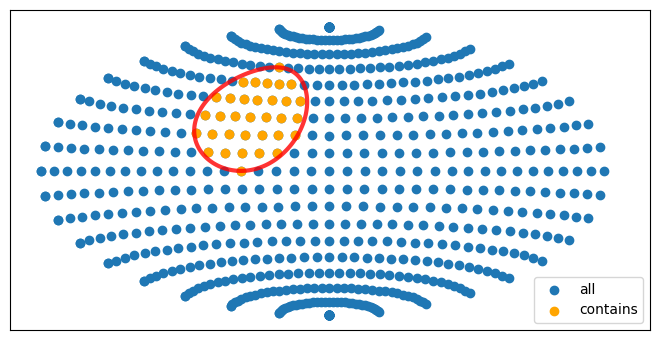

In [86]:
boundary_kwargs = dict(
    include_boundary_distortions=True, discretize_kwargs={"n_points":1000}
)

#----------------------------------------
# define skycoords
lon = np.arange(-180, 181, 10)
lat = np.arange(-90, 91, 10)
coords = np.array(np.meshgrid(lon, lat)).T.reshape(-1, 2)
skycoords = SkyCoord(coords, unit='deg', frame='icrs')


mask_and = sph_circ.contains(skycoords)
skycoords_and = skycoords[mask_and]


# plot
fig = plt.figure()
fig.set_size_inches(8,7)

axes = []
# (left, bottom, width, height)
axes.append(fig.add_axes([0.1, 0.1, 0.8, 0.8], projection=wcs, aspect='equal'))

# regions
ax = axes[0]

ax.scatter(skycoords.ra.value, skycoords.dec.value, label='all',
        transform=ax.get_transform('icrs'))
ax.scatter(skycoords_and.ra.value, skycoords_and.dec.value, color='orange',
        label='contains', transform=ax.get_transform('icrs'))

sph_circ.to_pixel(wcs=wcs,**boundary_kwargs).plot(ax=ax, edgecolor='red', facecolor='none',
                            alpha=0.8, lw=3)


ax.legend(loc='lower right')

ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
_ = ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)

-----

#### B. Implements IVOA "Range" geometry (bounded by longitude and/or latitude):

In [61]:
lonlat_range = RangeSphericalSkyRegion(
    frame="galactic",
    longitude_range=[-45,45]*u.deg,
    latitude_range=[0,45]*u.deg,
)
lonlat_range

<RangeSphericalSkyRegion(
frame=<class 'astropy.coordinates.builtin_frames.galactic.Galactic'>,
longitude_range=[-45.  45.] deg,
latitude_range=[ 0. 45.] deg
)>

In [62]:
lonlat_range

<RangeSphericalSkyRegion(
frame=<class 'astropy.coordinates.builtin_frames.galactic.Galactic'>,
longitude_range=[-45.  45.] deg,
latitude_range=[ 0. 45.] deg
)>

In [63]:
# Lat only:
lat_range = RangeSphericalSkyRegion(
    frame="galactic",
    latitude_range=[35,80]*u.deg,
)

In [64]:
lat_range

<RangeSphericalSkyRegion(
frame=<class 'astropy.coordinates.builtin_frames.galactic.Galactic'>,
longitude_range=None,
latitude_range=[35. 80.] deg
)>

In [65]:
# Lon only:
lon_range = RangeSphericalSkyRegion(
    frame="galactic",
    longitude_range=[50,140]*u.deg,
)

In [66]:
lon_range

<RangeSphericalSkyRegion(
frame=<class 'astropy.coordinates.builtin_frames.galactic.Galactic'>,
longitude_range=[ 50. 140.] deg,
latitude_range=None
)>

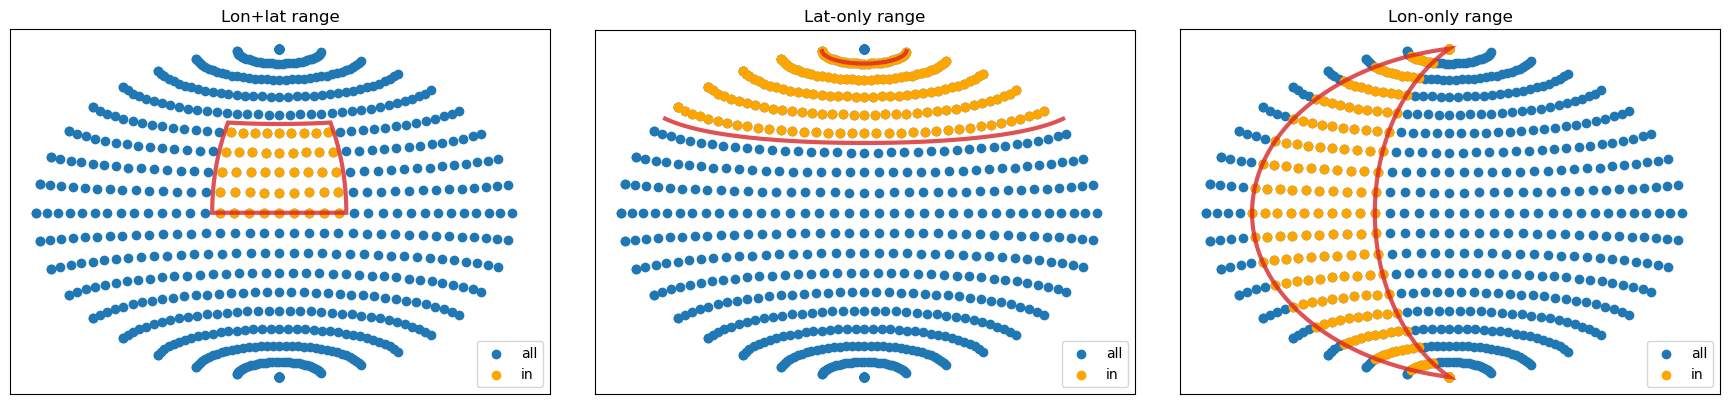

In [67]:

# load example dataset to get skymap
config = dict(crval=(0, 0),
            crpix=(180, 90),
            cdelt=(-1, 1),
            shape=(180, 360),
             ctype =('GLON-AIT', 'GLAT-AIT'))

dataset = make_example_dataset(data='simulated', config=config)
wcs = dataset.wcs

# remove sources
dataset.image.data = np.zeros_like(dataset.image.data)

#----------------------------------------
# define skycoords
lon = np.arange(-180, 181, 10)
lat = np.arange(-90, 91, 10)
coords = np.array(np.meshgrid(lon, lat)).T.reshape(-1, 2)
skycoords = SkyCoord(coords, unit='deg', frame='galactic')

#----------------------------------------
# get events in region

mask_in = lonlat_range.contains(skycoords)
skycoords_in = skycoords[mask_in]


# plot
fig = plt.figure()
fig.set_size_inches(18,7)
axes = []
aspect = 1.35 # "equal"
axes.append(fig.add_axes([0.025, 0.1, 0.3, 0.8], projection=wcs, aspect=aspect))
axes.append(fig.add_axes([0.35, 0.1, 0.3, 0.8], projection=wcs, aspect=aspect))
axes.append(fig.add_axes([0.675, 0.1, 0.3, 0.8], projection=wcs, aspect=aspect))

# regions

ax = axes[0]

ax.scatter(skycoords.l.value, skycoords.b.value, label='all',
        transform=ax.get_transform('galactic'))
ax.scatter(skycoords_in.l.value, skycoords_in.b.value, color='orange',
        label='in', transform=ax.get_transform('galactic'))

lonlat_range.to_pixel(wcs=wcs, **boundary_kwargs).plot(ax=ax, edgecolor='tab:red', facecolor='none',
                            alpha=0.8, lw=3)

ax.legend(loc='lower right')

ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
_ = ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)
ax.set_title("Lon+lat range")

# ----------
ax = axes[1]

#----------------------------------------
# get events in region

mask_in = lat_range.contains(skycoords)
skycoords_in = skycoords[mask_in]

ax.scatter(skycoords.l.value, skycoords.b.value, label='all',
        transform=ax.get_transform('galactic'))
ax.scatter(skycoords_in.l.value, skycoords_in.b.value, color='orange',
        label='in', transform=ax.get_transform('galactic'))

pix_range = lat_range.to_pixel(wcs=wcs, **boundary_kwargs)
# # Kludge for MPL patch:
# pix_range.region1.center = 0
# pix_range.region2.center = 0
# # pix_range.plot(ax=ax, edgecolor='tab:red', facecolor='none',
# #                             alpha=0.8, lw=3)
ax.plot(
    pix_range.region1.vertices.x, pix_range.region1.vertices.y,
    color="tab:red", alpha=0.8, lw=3,
    # transform=ax.get_transform('icrs')
)
ax.plot(
    pix_range.region2.vertices.x, pix_range.region2.vertices.y,
    color="tab:red", alpha=0.8, lw=3,
    # transform=ax.get_transform('icrs')
)

# ax.plot(
#     lat_range.latitude_bounds.vertices.ra.value, lat_range.latitude_bounds.vertices.dec.value,
#     color="tab:red", alpha=0.8, lw=3,
#     transform=ax.get_transform('icrs')
# )

ax.legend(loc='lower right')

ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
_ = ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)

_ = ax.set_title("Lat-only range")

# -------
ax = axes[2]


#----------------------------------------
# get events in region

mask_in = lon_range.contains(skycoords)
skycoords_in = skycoords[mask_in]

# regions

ax.scatter(skycoords.l.value, skycoords.b.value, label='all',
        transform=ax.get_transform('galactic'))
ax.scatter(skycoords_in.l.value, skycoords_in.b.value, color='orange',
        label='in', transform=ax.get_transform('galactic'))

lon_range.to_pixel(wcs=wcs, **boundary_kwargs).plot(ax=ax, edgecolor='tab:red', facecolor='none',
                            alpha=0.8, lw=3)

ax.legend(loc='lower right')

ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
_ = ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)


_ = ax.set_title("Lon-only range")

-----

#### C. Transform between coordinate frames

Follows same convention as SkyCoord transformation
(Again, vetting of same frame origin has not been implemented)

In [68]:
c = SkyCoord(0,0,unit=u.deg,frame="galactic")
c

<SkyCoord (Galactic): (l, b) in deg
    (0., 0.)>

In [69]:
c.transform_to("icrs")

<SkyCoord (ICRS): (ra, dec) in deg
    (266.40498829, -28.93617776)>

In [70]:
sph_circ

<CircleSphericalSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (50., 30.)>, radius=30.0 deg)>

In [71]:
sph_circ.transform_to("galactic")

<CircleSphericalSkyRegion(center=<SkyCoord (Galactic): (l, b) in deg
    (157.46751656, -22.73184648)>, radius=30.0 deg)>

In [72]:
lonlat_range

<RangeSphericalSkyRegion(
frame=<class 'astropy.coordinates.builtin_frames.galactic.Galactic'>,
longitude_range=[-45.  45.] deg,
latitude_range=[ 0. 45.] deg
)>

In [73]:
# Note the transformed "range" instance exposes the lune and circular annulus boundaries
# that capture the *original* frame lon/lat ranges,
# because in the new frame it is not represented by a simple lon/lat range.
lonlat_range_transf = lonlat_range.transform_to("icrs")
lonlat_range_transf

<RangeSphericalSkyRegion(
frame=<class 'astropy.coordinates.builtin_frames.icrs.ICRS'>,
longitude_bounds=<LuneSphericalSkyRegion(center_gc1=<SkyCoord (ICRS): (ra, dec) in deg
    (288.42757587, 10.72370325)>, center_gc2=<SkyCoord (ICRS): (ra, dec) in deg
    (217.98010947, -60.49575721)>)>,
latitude_bounds=<CircleAnnulusSphericalSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (192.85947789, 27.12825241)>, inner_radius=45.0 deg, outer_radius=90.0 deg)>
)>

In [80]:
# plot
fig = plt.figure(figsize=(14,8))


# axes = []
# for i in range(2):
#     axes.append(fig.add_subplot((1,i+1,1), **dict(projection=wcs, aspect='equal')))
axes = []

# load example dataset to get skymap
config = dict(crval=(0, 0),
            crpix=(180, 90),
            cdelt=(-1, 1),
            shape=(180, 360),
             ctype =('GLON-AIT', 'GLAT-AIT'))

dataset = make_example_dataset(data='simulated', config=config)
wcs = dataset.wcs

# remove sources
dataset.image.data = np.zeros_like(dataset.image.data)

# load example dataset to get skymap
config_icrs = dict(crval=(0, 0),
            crpix=(180, 90),
            cdelt=(-1, 1),
            shape=(180, 360),
             ctype =('RA---AIT', 'DEC--AIT'))

dataset_icrs = make_example_dataset(data='simulated', config=config_icrs)
wcs_icrs = dataset_icrs.wcs

# remove sources
dataset_icrs.image.data = np.zeros_like(dataset_icrs.image.data)

# (left, bottom, width, height)
# axes.append(fig.add_axes([0.05, 0.1, 0.45, 0.8], projection="aitoff", aspect='equal'))
# axes.append(fig.add_axes([0.55, 0.1, 0.45, 0.8], projection="aitoff", aspect='equal'))
axes.append(fig.add_axes([0.05, 0.55, 0.45, 0.4], projection="aitoff"))#, aspect='equal'))
axes.append(fig.add_axes([0.55, 0.55, 0.45, 0.4], projection="aitoff"))#, aspect='equal'))

axes.append(fig.add_axes([0.05, 0.05, 0.45, 0.4], projection=wcs, aspect='equal'))
axes.append(fig.add_axes([0.55, 0.05, 0.45, 0.4], projection=wcs_icrs, aspect='equal'))

# ------------------------------
# Galactic frame
ind = 0
ax = axes[ind]
ax.set_title("Galactic, Aitoff projection", pad=15)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$b$")
ax.grid(True)
poly_galactic = lonlat_range.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(poly_galactic.vertices.l).wrap_at(180 * u.deg).radian,
    Angle(poly_galactic.vertices.b).radian,
    lw=3, color="tab:red",
)

# ------------------------------
# ICRS frame
ind = 1
ax = axes[ind]
ax.set_title("ICRS, Aitoff projection", pad=15)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(True)
poly_icrs = lonlat_range_transf.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(poly_icrs.vertices.ra).wrap_at(180 * u.deg).radian,
    Angle(poly_icrs.vertices.dec).radian,
    lw=3, color="tab:red",
)

# ------------------------------
# Galactic frame, points
ind = 2
ax = axes[ind]


#----------------------------------------
# define skycoords
fac = 1
# fac = 2
# lon = np.arange(-180, 181, 10)
# lat = np.arange(-90, 91, 10)
lon = np.arange(-180, 180+1./fac, 1./fac)
lat = np.arange(-90, 90+1./fac, 1./fac)
coords = np.array(np.meshgrid(lon, lat)).T.reshape(-1, 2)
skycoords = SkyCoord(coords, unit='deg', frame='galactic')

ms = 2
mk = "."
lw_mk = 0

#----------------------------------------
# get events in region

mask_in = lonlat_range.contains(skycoords)
skycoords_in = skycoords[mask_in]

ax.scatter(skycoords.l.value, skycoords.b.value, label='all',s=ms, marker=mk, lw=lw_mk,
        transform=ax.get_transform('galactic'))
ax.scatter(skycoords_in.l.value, skycoords_in.b.value, color='orange',s=ms, marker=mk, lw=lw_mk,
        label='in', transform=ax.get_transform('galactic'))

lonlat_range.to_pixel(wcs=wcs, **boundary_kwargs).plot(ax=ax, edgecolor='tab:red', facecolor='none',
                            alpha=0.8, lw=3)

ax.legend(loc='lower right')

# ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
ax.set_xlim(dataset.config['shape'][1] - 0.5,-0.5)
ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)
ax.set_title("Galactic, Aitoff projection")


# ------------------------------
# ICRS frame, points
ind = 3
ax = axes[ind]

#----------------------------------------
# get events in region

skycoords_transf = skycoords.transform_to('icrs')

mask_in = lonlat_range_transf.contains(skycoords_transf)
skycoords_transf_in = skycoords_transf[mask_in]

ax.scatter(skycoords_transf.ra.value, skycoords_transf.dec.value, label='all', s=ms, marker=mk, lw=lw_mk,
        transform=ax.get_transform('icrs'))
ax.scatter(skycoords_transf_in.ra.value, skycoords_transf_in.dec.value, color='orange',s=ms, marker=mk, lw=lw_mk,
        label='in', transform=ax.get_transform('icrs'))


lonlat_range_transf.to_pixel(wcs=wcs_icrs, **boundary_kwargs).plot(ax=ax, edgecolor='tab:red', facecolor='none',
                            alpha=0.8, lw=3)



ax.legend(loc='lower right')

# # ax.set_xlim(-0.5, dataset_icrs.config['shape'][1] - 0.5)
ax.set_xlim(dataset_icrs.config['shape'][1] - 0.5,-0.5)
ax.set_ylim(-0.5, dataset_icrs.config['shape'][0] - 0.5)
ax.set_title("ICRS, Aitoff projection")

Text(0.5, 1.0, 'ICRS, Aitoff projection')

#### D. Other methods:


- `bounding_circle(), bounding_lonlat()`: boundary information, useful for queries or pre-trimming tables before, e.g., using `contains()`
- `discretize_boundary()`: a polygon approximation by discretizing the boundary(/ies), in order to account for boundary distortions in spherical to planar transformations.

In [74]:
lonlat_range_transf.bounding_circle

<CircleSphericalSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (251.64674219, -19.64298539)>, radius=47.26579039910021 deg)>

In [75]:
lonlat_range_transf.bounding_lonlat

(<Longitude [201.75437889, 288.42757587] deg>,
 <Latitude [-60.49575721,  27.00079109] deg>)

In [77]:
sph_circ3 = CircleSphericalSkyRegion(SkyCoord(0,60,unit=u.deg,frame="galactic"),20*u.deg)
sph_circ3_transf = sph_circ.transform_to("icrs")

In [78]:
# plot
fig = plt.figure(figsize=(14,8))


# axes = []
# for i in range(2):
#     axes.append(fig.add_subplot((1,i+1,1), **dict(projection=wcs, aspect='equal')))
axes = []

# (left, bottom, width, height)
# axes.append(fig.add_axes([0.05, 0.1, 0.45, 0.8], projection="aitoff", aspect='equal'))
# axes.append(fig.add_axes([0.55, 0.1, 0.45, 0.8], projection="aitoff", aspect='equal'))
axes.append(fig.add_axes([0.05, 0.55, 0.45, 0.4], projection="aitoff"))#, aspect='equal'))
axes.append(fig.add_axes([0.55, 0.55, 0.45, 0.4], projection="aitoff"))#, aspect='equal'))

axes.append(fig.add_axes([0.05, 0.05, 0.45, 0.4], projection="aitoff"))#, aspect='equal'))
axes.append(fig.add_axes([0.55, 0.05, 0.45, 0.4], projection="aitoff"))#, aspect='equal'))

# ----------------------------------------
# RANGE
# ------------------------------
# Galactic frame
ind = 0
ax = axes[ind]
ax.set_title("Galactic, Aitoff projection", pad=15)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$b$")
ax.grid(True)
poly_galactic = lonlat_range.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(poly_galactic.vertices.l).wrap_at(180 * u.deg).radian,
    Angle(poly_galactic.vertices.b).radian,
    lw=3, color="tab:red",
)

bound_lon, bound_lat = lonlat_range.bounding_lonlat
ax.axvline(x=bound_lon[0].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axvline(x=bound_lon[1].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[0].radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[1].radian,  ls='--', color='black', zorder=-10)

bound_circ = lonlat_range.bounding_circle.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(bound_circ.vertices.l).wrap_at(180 * u.deg).radian,
    Angle(bound_circ.vertices.b).radian,
    ls="--", color="black", zorder=-10
)

# ------------------------------
# ICRS frame
ind = 1
ax = axes[ind]
ax.set_title("ICRS, Aitoff projection", pad=15)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(True)
poly_icrs = lonlat_range_transf.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(poly_icrs.vertices.ra).wrap_at(180 * u.deg).radian,
    Angle(poly_icrs.vertices.dec).radian,
    lw=3, color="tab:red",
)

bound_lon, bound_lat = lonlat_range_transf.bounding_lonlat
ax.axvline(x=bound_lon[0].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axvline(x=bound_lon[1].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[0].radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[1].radian,  ls='--', color='black', zorder=-10)

bound_circ = lonlat_range_transf.bounding_circle.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(bound_circ.vertices.ra).wrap_at(180 * u.deg).radian,
    Angle(bound_circ.vertices.dec).radian,
    ls="--", color="black", zorder=-10
)

# ----------------------------------------
# CIRCLE

# ------------------------------
# Galactic frame
ind = 2
ax = axes[ind]
ax.set_title("Galactic, Aitoff projection", pad=15)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$b$")
ax.grid(True)
poly_galactic = sph_circ3.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(poly_galactic.vertices.l).wrap_at(180 * u.deg).radian,
    Angle(poly_galactic.vertices.b).radian,
    lw=3, color="tab:red",
)

bound_lon, bound_lat = sph_circ3.bounding_lonlat
ax.axvline(x=bound_lon[0].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axvline(x=bound_lon[1].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[0].radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[1].radian,  ls='--', color='black', zorder=-10)

bound_circ = sph_circ3.bounding_circle.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(bound_circ.vertices.l).wrap_at(180 * u.deg).radian,
    Angle(bound_circ.vertices.b).radian,
    ls="--", color="black", zorder=-10
)

# ------------------------------
# ICRS frame
ind = 3
ax = axes[ind]
ax.set_title("ICRS, Aitoff projection", pad=15)
ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.grid(True)
poly_icrs = sph_circ3_transf.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(poly_icrs.vertices.ra).wrap_at(180 * u.deg).radian,
    Angle(poly_icrs.vertices.dec).radian,
    lw=3, color="tab:red",
)

bound_lon, bound_lat = sph_circ3_transf.bounding_lonlat
ax.axvline(x=bound_lon[0].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axvline(x=bound_lon[1].wrap_at(180*u.deg).radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[0].radian,  ls='--', color='black', zorder=-10)
ax.axhline(y=bound_lat[1].radian,  ls='--', color='black', zorder=-10)

bound_circ = sph_circ3_transf.bounding_circle.discretize_boundary(**boundary_kwargs['discretize_kwargs'])
ax.plot(
    Angle(bound_circ.vertices.ra).wrap_at(180 * u.deg).radian,
    Angle(bound_circ.vertices.dec).radian,
    ls="--", color="black", zorder=-10
)

----

In [78]:
# Discretize:

# n_points per "edge": circle circumference = 1 edge
sph_circ.discretize_boundary(n_points=10)

<PolygonSphericalSkyRegion(vertices=<SkyCoord (ICRS): (ra, dec) in deg
    [(21.78424646, 51.56624091), (14.74553774, 34.52883959),
     (20.1085386 , 17.40982491), (32.84829276,  4.74366771),
     (50.        ,  0.        ), (67.15170724,  4.74366771),
     (79.8914614 , 17.40982491), (85.25446226, 34.52883959),
     (78.21575354, 51.56624091), (50.        , 60.        )]>)>

In [82]:
# For lon+lat range, all four sides get n_points:
lonlat_range.discretize_boundary(n_points=2)

<PolygonSphericalSkyRegion(vertices=<SkyCoord (ICRS): (ra, dec) in deg
    [( 50., 80. ), ( 50., 57.5), ( 50., 35. ), ( 95., 35. ), (140., 35. ),
     (140., 57.5), (140., 80. ), ( 95., 80. )]>)>

-----
### 2. Ability to convert to and from `SkyRegions` and `PixelRegions`

#### Not accounting for boundary distortions:
Using `include_boundary_distortions=False` (the default) in `to_sky()` and `to_spherical_sky()` methods

In [8]:
circ = CircleSkyRegion(SkyCoord(0,0,unit=u.deg,frame="icrs"),1*u.deg)
sph_circ = CircleSphericalSkyRegion(SkyCoord(0,0,unit=u.deg,frame="icrs"),1*u.deg)

In [13]:
circ

<CircleSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (0., 0.)>, radius=1.0 deg)>

In [12]:
sph_circ.to_sky() # uses default `include_boundary_distortions=False`

<CircleSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (0., 0.)>, radius=1.0 deg)>

In [14]:
assert circ == sph_circ.to_sky()

In [15]:
sph_circ

<CircleSphericalSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (0., 0.)>, radius=1.0 deg)>

In [10]:
circ.to_spherical_sky() # uses default `include_boundary_distortions=False`

<CircleSphericalSkyRegion(center=<SkyCoord (ICRS): (ra, dec) in deg
    (0., 0.)>, radius=1.0 deg)>

In [ ]:
assert sph_circ == circ.to_spherical_sky()

**When ignoring boundary distortions, conversions are round-trippable:**

In [16]:
assert circ == circ.to_spherical_sky().to_sky()

**The spherical sky region `to_pixel()` methods can be called as usual** (ignoring distortions by default):

In [31]:
sph_circ.to_pixel(wcs)

<CirclePixelRegion(center=PixCoord(x=179.0, y=89.0), radius=1.0000000000161435)>

-----

#### Including boundary distortions:
Requires a WCS instance

(Again, conversion is not yet implemented for `to_spherical_sky()`, as planar pixel space discretization has not been implemented)

In [24]:
# Override default CircleSphericalSkyRegion discretize_kwargs={"n_points": 100}
sph_circ.to_sky(include_boundary_distortions=True, wcs=wcs, discretize_kwargs={"n_points": 10})

<PolygonSkyRegion(vertices=<SkyCoord (ICRS): (ra, dec) in deg
    [(359.41217568,  0.8090028), (359.04893426,  0.3090028),
     (359.04893426, -0.3090028), (359.41217568, -0.8090028),
     (  0.        , -1.       ), (  0.58782432, -0.8090028),
     (  0.95106574, -0.3090028), (  0.95106574,  0.3090028),
     (  0.58782432,  0.8090028), (  0.        ,  1.       )]>)>

In [23]:
# Override default CircleSphericalSkyRegion discretize_kwargs={"n_points": 100}
sph_circ.to_pixel(include_boundary_distortions=True, wcs=wcs, discretize_kwargs={"n_points": 10})

<PolygonPixelRegion(vertices=PixCoord(x=[179.58777973 179.95105263 179.95105263 179.58777973 179.
 178.41222027 178.04894737 178.04894737 178.41222027 179.        ], y=[89.80899874 89.30900509 88.69099491 88.19100126 88.00001269 88.19100126
 88.69099491 89.30900509 89.80899874 89.99998731]))>

In [32]:
# Also:
sph_circ.to_pixel(wcs,include_boundary_distortions=True, discretize_kwargs={"n_points": 10})

<PolygonPixelRegion(vertices=PixCoord(x=[179.58777973 179.95105263 179.95105263 179.58777973 179.
 178.41222027 178.04894737 178.04894737 178.41222027 179.        ], y=[89.80899874 89.30900509 88.69099491 88.19100126 88.00001269 88.19100126
 88.69099491 89.30900509 89.80899874 89.99998731]))>

#### Demonstration of boundary distortion converting from spherical circles -> to planar representations:

In [33]:
rad = 15*u.deg

circs = []
for lat in [-90,-60,-30,0,30,60,90]:
    for lon in [0,30,60,90,120,150,180,210,240,270,300,330]:
        circs.append(CircleSphericalSkyRegion(SkyCoord(lon, lat, unit=u.deg), radius=rad))

circs_poly = [ c.discretize_boundary(n_points=100) for c in circs ]

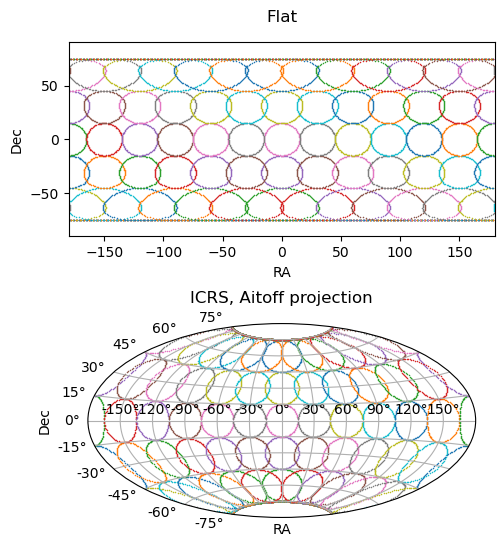

In [34]:
fig = plt.figure(figsize=(5.5,5))
axes = []
axes.append(fig.add_subplot(211))
axes.append(fig.add_subplot(212, **dict(projection="aitoff")))


axes[0].set_title("Flat", pad=15)
axes[0].set_xlabel("RA")
axes[0].set_ylabel("Dec")

axes[1].set_title("ICRS, Aitoff projection", pad=15)
axes[1].set_xlabel("RA")
axes[1].set_ylabel("Dec")
axes[1].grid(True)


for cpoly in circs_poly:

    axes[0].scatter(
        Angle(cpoly.vertices.ra).wrap_at(180 * u.deg), cpoly.vertices.dec,
        marker=".", s=5, lw=0
    )

    axes[1].scatter(
        Angle(cpoly.vertices.ra).wrap_at(180 * u.deg).radian,
        Angle(cpoly.vertices.dec).radian,
        marker=".", s=5, lw=0
    )

# axes[0].set_xlim([0,360])
axes[0].set_xlim([-180,180])
axes[0].set_ylim([-90,90])

fig.subplots_adjust(top=0.95, bottom=0.0, hspace=0.45)

plt.show()

----
### 3. Ability to construct compound spherical sky regions

In [43]:
boundary_kwargs = dict(
    include_boundary_distortions=True, discretize_kwargs={"n_points":1000}
)

#----------------------------------------
# define 2 sky circles
circle1 = CircleSkyRegion(
    center=SkyCoord(20, 0, unit='deg', frame='galactic'),
    radius=Angle('30 deg'))

circle2 = CircleSkyRegion(
    center=SkyCoord(50, 45, unit='deg', frame='galactic'),
    radius=Angle('30 deg'))

#----------------------------------------
# get events in AND and XOR
# regions
compound_and = circle1 & circle2
compound_xor = circle1 ^ circle2

#----------------------------------------
# Spherical sky circles
sph_circle1 = circle1.to_spherical_sky()
sph_circle2 = circle2.to_spherical_sky()


#----------------------------------------
# get events in AND and XOR
# spherical regions
sph_compound_and = sph_circle1 & sph_circle2
sph_compound_xor = sph_circle1 ^ sph_circle2


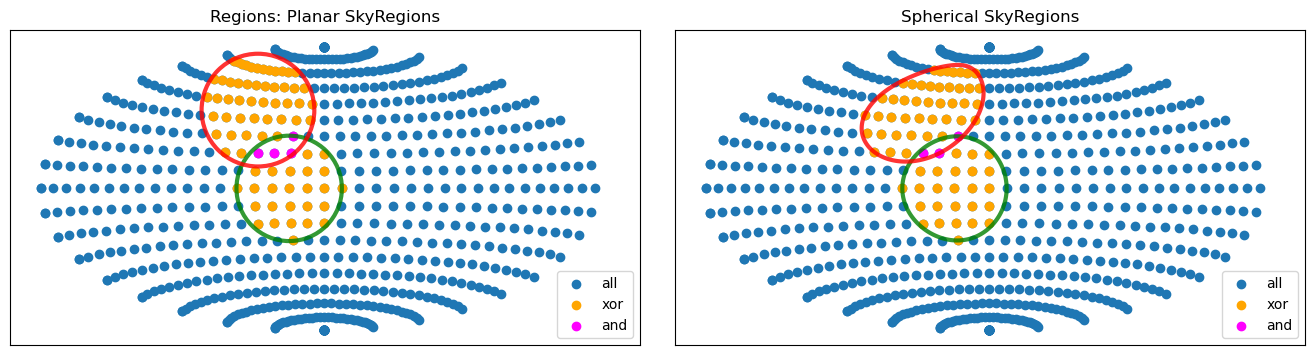

In [44]:
# load example dataset to get skymap
config = dict(crval=(0, 0),
            crpix=(180, 90),
            cdelt=(-1, 1),
            shape=(180, 360))

dataset = make_example_dataset(data='simulated', config=config)
wcs = dataset.wcs

# remove sources
dataset.image.data = np.zeros_like(dataset.image.data)

#----------------------------------------
# define skycoords
lon = np.arange(-180, 181, 10)
lat = np.arange(-90, 91, 10)
coords = np.array(np.meshgrid(lon, lat)).T.reshape(-1, 2)
skycoords = SkyCoord(coords, unit='deg', frame='galactic')

#----------------------------------------
# get events in AND and XOR

mask_and = compound_and.contains(skycoords, wcs)
skycoords_and = skycoords[mask_and]
mask_xor = compound_xor.contains(skycoords, wcs)
skycoords_xor = skycoords[mask_xor]


#----------------------------------------
# get events in AND and XOR

sph_mask_and = sph_compound_and.contains(skycoords)
sph_skycoords_and = skycoords[sph_mask_and]
sph_mask_xor = sph_compound_xor.contains(skycoords)
sph_skycoords_xor = skycoords[sph_mask_xor]

# plot
fig = plt.figure()
fig.set_size_inches(14,7)

# axes = []
# for i in range(2):
#     axes.append(fig.add_subplot((1,i+1,1), **dict(projection=wcs, aspect='equal')))
axes = []
# (left, bottom, width, height)
axes.append(fig.add_axes([0.05, 0.1, 0.45, 0.8], projection=wcs, aspect='equal'))
axes.append(fig.add_axes([0.525, 0.1, 0.45, 0.8], projection=wcs, aspect='equal'))

# regions
ax = axes[0]

ax.scatter(skycoords.l.value, skycoords.b.value, label='all',
        transform=ax.get_transform('galactic'))
ax.scatter(skycoords_xor.l.value, skycoords_xor.b.value, color='orange',
        label='xor', transform=ax.get_transform('galactic'))
ax.scatter(skycoords_and.l.value, skycoords_and.b.value, color='magenta',
        label='and', transform=ax.get_transform('galactic'))

circle1.to_pixel(wcs=wcs).plot(ax=ax, edgecolor='green', facecolor='none',
                            alpha=0.8, lw=3)
circle2.to_pixel(wcs=wcs).plot(ax=ax, edgecolor='red', facecolor='none',
                            alpha=0.8, lw=3)


ax.legend(loc='lower right')

ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)
ax.set_title("Regions: Planar SkyRegions")


# spherical regions
ax = axes[1]

ax.scatter(skycoords.l.value, skycoords.b.value, label='all',
        transform=ax.get_transform('galactic'))
ax.scatter(sph_skycoords_xor.l.value, sph_skycoords_xor.b.value, color='orange',
        label='xor', transform=ax.get_transform('galactic'))
ax.scatter(sph_skycoords_and.l.value, sph_skycoords_and.b.value, color='magenta',
        label='and', transform=ax.get_transform('galactic'))

sph_circle1.to_pixel(wcs=wcs,**boundary_kwargs).plot(ax=ax, edgecolor='green', facecolor='none',
                            alpha=0.8, lw=3)
sph_circle2.to_pixel(wcs=wcs,**boundary_kwargs).plot(ax=ax, edgecolor='red', facecolor='none',
                            alpha=0.8, lw=3)

ax.legend(loc='lower right')

ax.set_xlim(-0.5, dataset.config['shape'][1] - 0.5)
ax.set_ylim(-0.5, dataset.config['shape'][0] - 0.5)
_ = ax.set_title("Spherical SkyRegions")
